Waled Mahaya 22407572
Omar Nassr 2240
1: Imports and Training Data Setup
First, we will set up our environment and create a custom training dataset. Since the prompt specifies binary attributes, we will use a dataset where all features and the target variable are encoded as 0 (False/No) or 1 (True/Yes). Let's use a "Movie Recommendation" dataset.

In [ ]:
import numpy as np
import pandas as pd

shroom_df_x = pd.read_csv("mushrooms.csv")

target_attribute = "class"

feature_attributes = [
    col for col in shroom_df_x.columns
    if col != target_attribute
]

shroom_df_x = pd.get_dummies(
    shroom_df_x,
    columns=feature_attributes,
    drop_first=True
)

shroom_df_x[target_attribute] = (
    shroom_df_x[target_attribute]
    .map({"p": 1, "e": 0})
)

shroom_df_x = shroom_df_x.astype(int)

# Generic names used later
df = shroom_df_x

feature_attributes = [
    col for col in df.columns
    if col != target_attribute
]

To calculate IMPORTANCE(a, examples), we use Information Gain

In [2]:
def plurality_val(examples, target_col):
    """Returns the most common class in the target column."""
    if len(examples) == 0:
        return None
    return examples[target_col].mode()[0]

def entropy(target_col):
    """Calculates the Shannon entropy of a dataset's target variable."""
    if len(target_col) == 0:
        return 0
    # Get probabilities of each class
    counts = target_col.value_counts()
    probs = counts / len(target_col)
    # Calculate entropy (-p * log2(p))
    return -np.sum(probs * np.log2(probs))

def importance(attribute, examples, target_col):
    """Calculates the Information Gain of a specific attribute."""
    # 1. Calculate parent entropy
    parent_entropy = entropy(examples[target_col])
    
    # 2. Calculate weighted average entropy of children
    weighted_child_entropy = 0
    for value in [0, 1]: # Since attributes are binary
        subset = examples[examples[attribute] == value]
        if len(subset) > 0:
            weight = len(subset) / len(examples)
            weighted_child_entropy += weight * entropy(subset[target_col])
            
    # 3. Information Gain
    return parent_entropy - weighted_child_entropy

3: Algorithm 4 Implementation
Here is the exact translation of Algorithm 4 from your prompt into recursive Python code.

In [6]:
def dt_learning(examples, attributes, parent_examples, target_col):
    """
    ID3 Decision Tree Learning Algorithm
    """

    # No examples
    if examples.empty:
        return plurality_val(parent_examples, target_col)

    # All examples belong to one class
    if examples[target_col].nunique() == 1:
        return examples[target_col].iloc[0]

    # No attributes left
    if not attributes:
        return plurality_val(examples, target_col)

    # Choose attribute with highest information gain
    gains = {
        attr: importance(attr, examples, target_col)
        for attr in attributes
    }

    best_attr = max(gains, key=gains.get)

    tree = {best_attr: {}}

    remaining_attributes = [
        attr for attr in attributes
        if attr != best_attr
    ]

    # Works for any categorical attribute
    for value in sorted(examples[best_attr].unique()):

        subset = examples[examples[best_attr] == value]

        tree[best_attr][value] = dt_learning(
            subset,
            remaining_attributes,
            examples,
            target_col
        )

    return tree


learned_tree = dt_learning(
    df,
    feature_attributes,
    df,
    target_attribute
)

NameError: name 'df' is not defined

In [ ]:
def dt_learning(examples, attributes, parent_examples, target_col):
    """
    ID3 Decision Tree Learning Algorithm
    """

    # No examples
    if examples.empty:
        return plurality_val(parent_examples, target_col)

    # All examples belong to one class
    if examples[target_col].nunique() == 1:
        return examples[target_col].iloc[0]

    # No attributes left
    if not attributes:
        return plurality_val(examples, target_col)

    # Choose attribute with highest information gain
    gains = {
        attr: importance(attr, examples, target_col)
        for attr in attributes
    }

    best_attr = max(gains, key=gains.get)

    tree = {best_attr: {}}

    remaining_attributes = [
        attr for attr in attributes
        if attr != best_attr
    ]

    # Works for any categorical attribute
    for value in sorted(examples[best_attr].unique()):

        subset = examples[examples[best_attr] == value]

        tree[best_attr][value] = dt_learning(
            subset,
            remaining_attributes,
            examples,
            target_col
        )

    return tree


learned_tree = dt_learning(
    df,
    feature_attributes,
    df,
    target_attribute
)

NameError: name 'df' is not defined

4: Visualizing the Tree
Visualizing nested dictionaries can be tough. I have provided two methods below: a Text-based Printout (which is guaranteed to work cleanly) and a NetworkX Plot (for a nice graphical node representation).

Donee


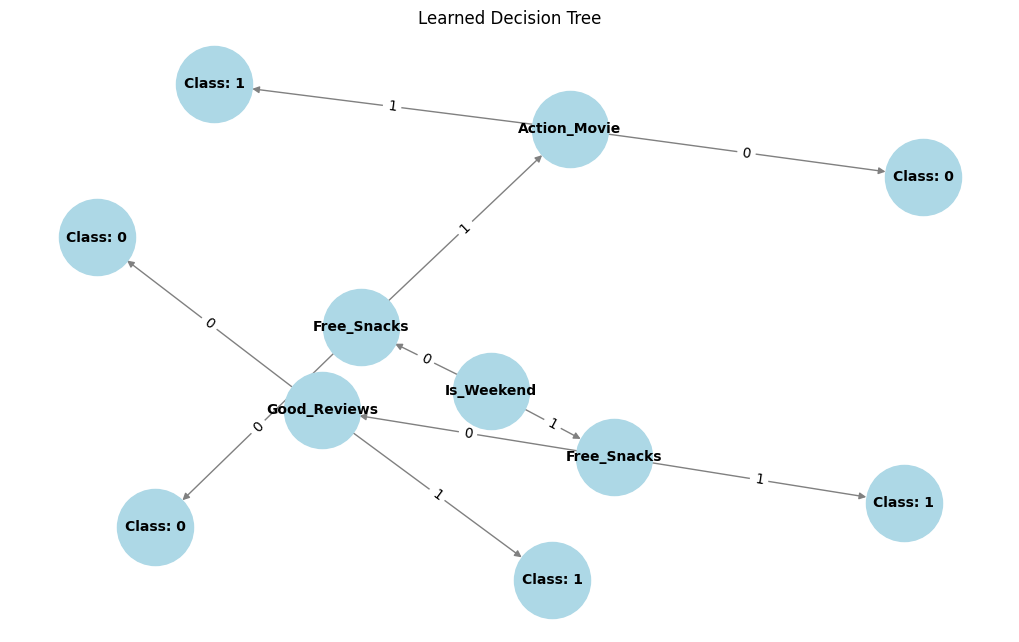

In [11]:
def print_tree(tree, indent=""):
    if not isinstance(tree, dict):
        print(f"───> Predict: {tree}")
        return
    
    for node, branches in tree.items():
        print(f"\n{indent}🔀 Split on [{node}]")
        for value, subtree in branches.items():
            print(f"{indent}   ├── If {node} == {value} ", end="")
            print_tree(subtree, indent + "   │")

def draw_tree(tree):
    graph = nx.DiGraph()
    labels = {}
    edge_labels = {}
    node_counter = [0]
    
    def add_nodes(sub_tree, parent_name=None, edge_label=""):
        current_node_id = f"Node_{node_counter[0]}"
        node_counter[0] += 1
        
        if not isinstance(sub_tree, dict):
            graph.add_node(current_node_id)
            labels[current_node_id] = f"Class: {sub_tree}"
            if parent_name:
                graph.add_edge(parent_name, current_node_id)
                edge_labels[(parent_name, current_node_id)] = edge_label
            return current_node_id
            
        feature = list(sub_tree.keys())[0]
        graph.add_node(current_node_id)
        labels[current_node_id] = feature
        
        if parent_name:
            graph.add_edge(parent_name, current_node_id)
            edge_labels[(parent_name, current_node_id)] = edge_label
            
        for branch_val, child_tree in sub_tree[feature].items():
            add_nodes(child_tree, current_node_id, str(branch_val))
            
        return current_node_id

    add_nodes(tree)
    plt.figure(figsize=(10, 6))
    try:
        pos = nx.nx_pydot.graphviz_layout(graph, prog="dot")
    except:
        # Fallback to standard networkx spring layout
        pos = nx.spring_layout(graph, seed=42)
        
    nx.draw(graph, pos, with_labels=False, node_size=3000, node_color="lightblue", 
            edge_color="gray", arrows=True)
    nx.draw_networkx_labels(graph, pos, labels, font_size=10, font_weight="bold")
    nx.draw_networkx_edge_labels(graph, pos, edge_labels=edge_labels, font_size=10)
    
    plt.title("Learned Decision Tree")
    plt.axis("off")
    plt.show()

draw_tree(learned_tree)

In [ ]:
# Visualization
import matplotlib.pyplot as plt
import pandas as pd

if 'df' in globals() and isinstance(df,pd.DataFrame):
    num=df.select_dtypes('number')
    if not num.empty:
        num.hist(figsize=(10,8))
        plt.tight_layout()
        plt.show()
